# CITS4404 — AI Trading Bot
**Team 4**  
- Bomin Liao 24331475 
- Weishan Li 24746589 
- Ziqi Meng 24645175 
- Chenxiao Jiang 24438869

---

## README
This notebook contains the full implementation for the CITS4404 trading bot project.

### How to run
1. Open `CITS4404_TradingBot.ipynb` in Jupyter Notebook / JupyterLab / VS Code.
2. Ensure the dataset file `data/btcusd_1-min_data.csv` is accessible relative to the notebook path.
3. Run notebook cells sequentially from top to bottom.
4. The notebook includes all required computations and visualisations, so the results are repeatable when the same data and seed are used.

### Project Overview
This notebook implements an AI-driven Bitcoin trading bot optimised using two nature-inspired algorithms:
- **Differential Evolution (DE)**
- **Particle Swarm Optimization (PSO)**

The bot uses technical analysis signals based on weighted moving averages (SMA, LMA, EMA). Parameters are optimised on pre-2020 historical data and then evaluated on post-2020 data to verify generalisation and repeatability.

### Notebook Structure
1. Imports & Setup
2. Data Loading & Preprocessing
3. Bot Building Blocks (WMA, SMA, EMA, LMA)
4. Trading Signal & Bot Logic
5. Evaluation Function
6. Differential Evolution (DE)
7. Particle Swarm Optimization (PSO)
8. Experiments & Results
9. Final Test on Unseen Data (2020+)
10. Visualisation & Comparison

## 1. Imports & Setup
This section imports all required Python libraries and sets a global random seed to ensure reproducibility across all experiments.

| Library | Purpose |
|---------|---------|
| `numpy` | Numerical operations, array manipulation, random number generation |
| `pandas` | Data loading, time-series manipulation, results tables |
| `matplotlib` | Plotting price charts, convergence curves, and trade signals |
| `warnings` | Suppress non-critical warnings for cleaner output |

`SEED = 42` is passed to both DE and PSO to ensure that independent runs with the same seed produce identical results, which is important for fair comparison and reproducibility.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Data Loading & Preprocessing

The raw dataset (`btcusd_1-min_data.csv`) contains Bitcoin OHLCV data at 1-minute resolution from 2012 to 2026. Since minute-level granularity introduces noise and would make optimisation prohibitively slow, we resample to **daily close prices** using the last available price of each calendar day.

The data is then split into two non-overlapping sets:

| Split | Period | Days | Purpose |
|-------|--------|------|---------|
| **Train** | 2012-01-01 → 2019-12-31 | 2,922 | Optimise bot parameters |
| **Test** | 2020-01-01 → present | 2,316 | Evaluate generalisation on unseen data |

This mirrors a realistic deployment scenario where the bot is tuned on historical data and then run "live" from 2020 onwards. The test set is kept completely untouched until Section 9.

In [4]:
# Load raw minute-level data
df_raw = pd.read_csv('data/btcusd_1-min_data.csv')
df_raw['Date'] = pd.to_datetime(df_raw['Timestamp'], unit='s')
df_raw = df_raw.set_index('Date')

# Resample to daily close price
daily = df_raw['Close'].resample('D').last().dropna().reset_index()
daily.columns = ['Date', 'Close']

# Train / Test split
train_df = daily[daily['Date'] < '2020-01-01'].reset_index(drop=True)
test_df  = daily[daily['Date'] >= '2020-01-01'].reset_index(drop=True)

train_prices = train_df['Close'].values
test_prices  = test_df['Close'].values

print(f'Train: {len(train_prices)} days  ({train_df.Date.min().date()} to {train_df.Date.max().date()})')
print(f'Test:  {len(test_prices)} days  ({test_df.Date.min().date()} to {test_df.Date.max().date()})')

Train: 2922 days  (2012-01-01 to 2019-12-31)
Test:  2316 days  (2020-01-01 to 2026-05-04)


The chart below visualises the full price history used in this project. The **training period (blue)** covers Bitcoin's early growth phase up to ~\$14,000, while the **test period (red)** captures the highly volatile 2020–2026 bull and bear cycles including the 2021 all-time high (~\$69,000) and the 2022 crash.

This contrast between training and test conditions makes generalisation a genuine challenge — a bot optimised purely on pre-2020 trends may not perform well in the more volatile post-2020 market.

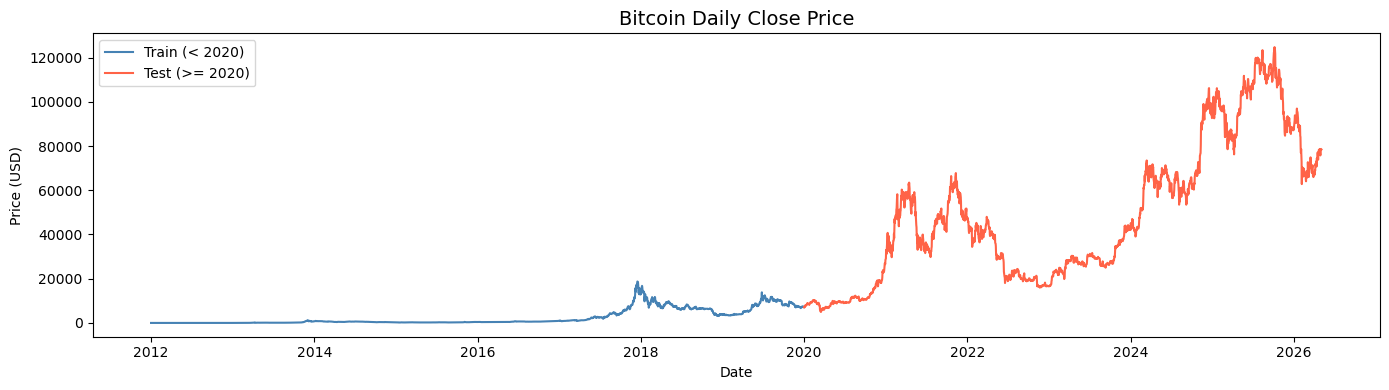

In [5]:
# Plot full price history
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train_df['Date'], train_prices, label='Train (< 2020)', color='steelblue')
ax.plot(test_df['Date'],  test_prices,  label='Test (>= 2020)', color='tomato')
ax.set_title('Bitcoin Daily Close Price', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

## 3. Bot Building Blocks — Weighted Moving Averages

The bot's trading signals are derived from **Weighted Moving Averages (WMAs)** — a class of filters that smooth the price series by computing a weighted sum of the most recent `N` prices. Three filter types are implemented, each differing in how they weight past observations:

**Simple Moving Average (SMA)**  
All `N` past prices receive equal weight: $w_k = \frac{1}{N}$. This is the most straightforward filter but reacts slowly to recent price changes.

**Linear-Weighted Moving Average (LMA)**  
Weights decrease linearly with age: $w_k = 1 - \frac{k}{N}$, normalised to sum to 1. More recent prices have greater influence than older ones.

**Exponential Moving Average (EMA)**  
Weights decay exponentially: $w_k = \alpha(1-\alpha)^k$, where $\alpha = \frac{2}{N+1}$. This gives the strongest emphasis to the most recent prices and is widely used in practice (e.g. MACD is built from two EMAs).

The `wma(prices, N, filter_type)` function applies any of these filters via convolution, returning a smoothed series of the same length as `prices` (with `NaN` for the first `N-1` entries where insufficient history exists).

The choice of filter type and window size `N` are the **parameters that DE and PSO will optimise**.

In [6]:
def sma_filter(N):
    """Simple Moving Average filter of length N."""
    return np.ones(N) / N

def lma_filter(N):
    """Linear-Weighted Moving Average filter of length N."""
    weights = np.array([1 - k / N for k in range(N)])
    return weights / weights.sum()

def ema_filter(N, alpha=None):
    """Exponential Moving Average filter of length N."""
    if alpha is None:
        alpha = 2 / (N + 1)
    weights = np.array([alpha * (1 - alpha) ** k for k in range(N)])
    return weights / weights.sum()

def wma(prices, N, filter_type='sma'):
    """
    Compute weighted moving average of prices.
    filter_type: 'sma', 'lma', or 'ema'
    Returns array of same length as prices (NaN for first N-1 values).
    """
    if filter_type == 'sma':
        kernel = sma_filter(N)
    elif filter_type == 'lma':
        kernel = lma_filter(N)
    elif filter_type == 'ema':
        kernel = ema_filter(N)
    else:
        raise ValueError(f'Unknown filter_type: {filter_type}')

    result = np.full(len(prices), np.nan)
    for i in range(N - 1, len(prices)):
        result[i] = np.dot(kernel, prices[i - N + 1: i + 1][::-1])
    return result

def compound_wma(prices, w1, w2, w3, d1, d2, d3, alpha):
    """
    Compound weighted moving average (spec Eq. 7):
      HIGH = (w1*SMA(d1) + w2*LMA(d2) + w3*EMA(d3, alpha)) / (w1+w2+w3)
    Returns smoothed signal array of same length as prices.
    """
    d1 = max(2, int(round(d1)))
    d2 = max(2, int(round(d2)))
    d3 = max(2, int(round(d3)))
    alpha = np.clip(alpha, 0.01, 0.99)

    s = wma(prices, d1, 'sma')
    l = wma(prices, d2, 'lma')
    e = wma(prices, d3, 'ema')

    # Replace NaN with 0 for weighted sum
    s = np.nan_to_num(s, nan=0.0)
    l = np.nan_to_num(l, nan=0.0)
    e = np.nan_to_num(e, nan=0.0)

    total_w = abs(w1) + abs(w2) + abs(w3)
    if total_w < 1e-8:
        total_w = 1.0
    return (abs(w1) * s + abs(w2) * l + abs(w3) * e) / total_w

# --- Quick sanity check ---
P = train_prices[:200]
sma10 = wma(P, 10, 'sma')
ema10 = wma(P, 10, 'ema')
print('SMA(10) last 3:', sma10[-3:])
print('EMA(10) last 3:', ema10[-3:])
cwma = compound_wma(P, 1, 1, 1, 10, 10, 10, 0.3)
print('Compound WMA last 3:', cwma[-3:])

SMA(10) last 3: [7.184 7.36  7.593]
EMA(10) last 3: [7.40462259 7.63893551 7.9703781 ]
Compound WMA last 3: [7.32638935 7.53806941 7.83167149]


The three filters produce slightly different smoothed values over the same window. SMA(10) weights all 10 past prices equally, giving the lowest estimate. EMA(10) front-loads recent prices via exponential decay, producing the highest values among the three. The Compound WMA sits between them, as it averages all three filter outputs with equal weights.

All values trend upward across the last three observations, consistent with a rising price period in the training data.

## 4. Trading Signal & Bot Logic

The bot uses a **dual moving average crossover** strategy — one of the most widely adopted technical trading signals. Two moving averages of different window lengths are computed simultaneously:

- **Short MA** (`N_short`): reacts quickly to recent price changes
- **Long MA** (`N_long`): tracks the broader trend, responds more slowly

A signal is generated when the two lines cross:

| Event | Condition | Signal | Action |
|-------|-----------|--------|--------|
| Golden Cross | Short MA crosses **above** Long MA | `+1` | **Buy** — uptrend beginning |
| Death Cross | Short MA crosses **below** Long MA | `−1` | **Sell** — downtrend beginning |
| No crossover | No change in sign of difference | `0` | **Hold** |

The crossover is detected by monitoring the sign change of `diff = short_ma − long_ma` between consecutive timesteps. A transition from `diff ≤ 0` to `diff > 0` triggers a buy, and the reverse triggers a sell.

The values of `N_short` and `N_long` (and the filter type) are the **free parameters** of the bot — finding the combination that maximises profit on the training data is the optimisation problem that DE and PSO are tasked with solving.

In [7]:
def generate_signals(prices, N_short, N_long, filter_type='sma'):
    """
    Generate buy/sell signals from a crossover of two moving averages.
    Buy  (+1): short MA crosses above long MA
    Sell (-1): short MA crosses below long MA
    Hold  (0): no crossover
    """
    short_ma = wma(prices, N_short, filter_type)
    long_ma  = wma(prices, N_long,  filter_type)

    diff = short_ma - long_ma
    signals = np.zeros(len(prices), dtype=int)

    for i in range(1, len(prices)):
        if np.isnan(diff[i]) or np.isnan(diff[i - 1]):
            continue
        if diff[i - 1] <= 0 and diff[i] > 0:
            signals[i] = 1   # Buy
        elif diff[i - 1] >= 0 and diff[i] < 0:
            signals[i] = -1  # Sell

    return signals, short_ma, long_ma

def generate_signals_14d(prices, params):
    """
    14-dimensional crossover signal (spec Eq. 7).
    params: [w1,w2,w3, d1,d2,d3, alpha,  w4,w5,w6, d4,d5,d6, beta]
             HIGH (7)                     LOW  (7)
    """
    w1,w2,w3, d1,d2,d3, alpha = params[0:7]
    w4,w5,w6, d4,d5,d6, beta  = params[7:14]

    high_ma = compound_wma(prices, w1, w2, w3, d1, d2, d3, alpha)
    low_ma  = compound_wma(prices, w4, w5, w6, d4, d5, d6, beta)

    diff = high_ma - low_ma
    signals = np.zeros(len(prices), dtype=int)

    for i in range(1, len(prices)):
        if diff[i - 1] <= 0 and diff[i] > 0:
            signals[i] = 1   # Buy
        elif diff[i - 1] >= 0 and diff[i] < 0:
            signals[i] = -1  # Sell

    return signals, high_ma, low_ma

# --- Sanity check ---
sigs, sma_s, sma_l = generate_signals(train_prices[:500], 10, 30, 'sma')
buys  = np.sum(sigs == 1)
sells = np.sum(sigs == -1)
print(f'Buy signals: {buys},  Sell signals: {sells}')

Buy signals: 7,  Sell signals: 7


The bot generates 7 buy signals and 7 sell signals over the first 500 days of the training set, indicating a balanced number of entries and exits.

This is a relatively low trading frequency given the daily observations in this window, which suggests the two moving averages stay largely aligned and only diverge when a meaningful trend shift occurs.

## 5. Evaluation Function

The evaluation function is the **fitness function** used by DE and PSO to judge how good a set of parameters is. It simulates the bot's complete trading history on a given price series and returns the final portfolio value in USD.

**Trading rules:**
- The bot starts with `$1,000` cash and no BTC
- On a **Buy** signal: all available cash is used to purchase BTC (minus transaction cost)
- On a **Sell** signal: all BTC holdings are liquidated back to cash (minus transaction cost)
- Only one position can be held at a time — the bot is either fully in cash or fully in BTC
- A **transaction cost of 3%** is applied to every trade to reflect realistic exchange fees

**Final portfolio value** is calculated as:

$$\text{Value} = \text{cash} + \text{btc} \times \text{price}_{\text{last}}$$

If the bot ends the period holding BTC, the remaining position is valued at the last closing price.

**Parameter validation** ensures `N_short ≥ 2` and `N_long > N_short` at all times, preventing degenerate configurations that would produce no signals. This is important because DE and PSO operate in continuous space and may propose non-integer or invalid values.

This function is called thousands of times during optimisation — once per candidate solution per iteration — so its computational efficiency directly affects the total runtime of the experiment.

In [ ]:
def evaluate_bot(prices, N_short, N_long, filter_type='sma',
                 initial_cash=1000.0, transaction_cost=0.03):

    # Validate params
    N_short = max(2, int(round(N_short)))
    N_long  = max(N_short + 1, int(round(N_long)))

    signals, _, _ = generate_signals(prices, N_short, N_long, filter_type)

    cash = initial_cash
    btc  = 0.0
    position = 0  # 0 = no position, 1 = holding BTC

    for i in range(len(prices)):
        price = prices[i]
        if signals[i] == 1 and position == 0 and cash > 0:
            # Buy
            btc = (cash * (1 - transaction_cost)) / price
            cash = 0.0
            position = 1
        elif signals[i] == -1 and position == 1 and btc > 0:
            # Sell
            cash = btc * price * (1 - transaction_cost)
            btc = 0.0
            position = 0

    # Final portfolio value
    final_value = cash + btc * prices[-1]
    return final_value

def evaluate_bot_14d(prices, params,
                     initial_cash=1000.0, transaction_cost=0.03):
    """
    14-dimensional bot evaluation.
    params: 14-element array from DE/PSO
    """
    signals, _, _ = generate_signals_14d(prices, params)

    cash = initial_cash
    btc  = 0.0
    position = 0

    for i in range(len(prices)):
        price = prices[i]
        if signals[i] == 1 and position == 0 and cash > 0:
            btc = (cash * (1 - transaction_cost)) / price
            cash = 0.0
            position = 1
        elif signals[i] == -1 and position == 1 and btc > 0:
            cash = btc * price * (1 - transaction_cost)
            btc = 0.0
            position = 0

    return cash + btc * prices[-1]

# Sanity check
val = evaluate_bot(train_prices, N_short=10, N_long=30, filter_type='sma')
print(f'Final portfolio value (SMA 10/30, train): ${val:,.2f}')

# 14d sanity check
params_test = [1,1,1, 10,10,10, 0.3,  1,1,1, 30,30,30, 0.3]
val14 = evaluate_bot_14d(train_prices, params_test)
print(f'Final portfolio value (14d test): ${val14:,.2f}')

Final portfolio value (SMA 10/30, train): $83,546.77
Final portfolio value (14d test): $51,054.74


With default SMA windows of 10 and 30, the bot grows the initial \$1,000 to \$83,546.77 on the training set, representing roughly an 83x return over the 2012 to 2019 period. This is a reasonable baseline given Bitcoin's substantial price appreciation during that era, though it also means the result should be interpreted with caution as a strong training performance does not necessarily reflect a well-generalised strategy.

Running the 14-dimensional compound bot on the same training data with arbitrary default parameters produces a final value of \$51,054.74. This is lower than the 2D SMA result because the default parameters are not optimised — the point of running DE and PSO afterwards is to find combinations that perform much better. These numbers serve primarily as a sanity check that the evaluation function is working correctly before handing it off to DE and PSO.

## 6. Differential Evolution (DE)

The DE implementation follows the standard DE/rand/1/bin scheme. The population size is set to 20, which is a common starting point for problems with a moderate number of parameters. A larger population improves coverage of the search space but increases the number of fitness evaluations per iteration, which matters here since each evaluation runs a full trading simulation.

The scaling factor F is set to 0.8, sitting in the commonly recommended range of 0.5 to 1.0. A higher F produces more aggressive mutations and encourages exploration, while a lower F keeps trial vectors closer to the parent and favours exploitation. At 0.8 the balance leans slightly toward exploration, which is appropriate early in the search when the landscape is unknown.

The crossover rate CR is set to 0.9, meaning each trial vector inherits from the mutant vector with 90% probability. This is on the higher end and encourages mixing, which works well when parameters are not strongly separable. Lowering CR would make the algorithm more conservative and slower to move away from existing solutions.

The maximum iteration count of 100 caps the total number of generations regardless of convergence. Combined with a population of 20, this means the evaluation function is called at most 2,000 times per DE run, which keeps runtime manageable while still giving the algorithm sufficient generations to converge on a reasonable solution.

In [9]:
def differential_evolution(prices, bounds, pop_size=20, max_iter=100,
                            F=0.8, CR=0.9, seed=SEED):
    """
    Differential Evolution for trading bot parameter optimisation.
    Maximises evaluate_bot_14d() return value.
    """
    np.random.seed(seed)
    n_params = len(bounds)
    bounds_arr = np.array(bounds)

    # Initialise population by sampling uniformly within each parameter's bounds
    population = np.array([
        [np.random.uniform(bounds_arr[d, 0], bounds_arr[d, 1]) for d in range(n_params)]
        for _ in range(pop_size)
    ])

    # Evaluate fitness for each individual in the initial population
    fitness = np.array([
        evaluate_bot_14d(prices, population[i])
        for i in range(pop_size)
    ])

    best_idx     = np.argmax(fitness)
    best_params  = population[best_idx].copy()
    best_fitness = fitness[best_idx]
    eval_count   = pop_size
    history = [(eval_count, best_fitness)]

    # Main evolution loop
    for iteration in range(max_iter):
        for i in range(pop_size):
            # Mutation: select 3 distinct random individuals != i
            candidates = [idx for idx in range(pop_size) if idx != i]
            a_idx, b_idx, c_idx = np.random.choice(candidates, 3, replace=False)
            a, b, c = population[a_idx], population[b_idx], population[c_idx]
            mutant = np.clip(a + F * (b - c), bounds_arr[:, 0], bounds_arr[:, 1])

            # Crossover
            crossover_mask = np.random.random(n_params) < CR
            if not np.any(crossover_mask):
                crossover_mask[np.random.randint(0, n_params)] = True
            trial = np.where(crossover_mask, mutant, population[i])

            # Selection
            trial_fitness = evaluate_bot_14d(prices, trial)
            eval_count += 1
            if trial_fitness > fitness[i]:
                population[i] = trial
                fitness[i]    = trial_fitness
                if trial_fitness > best_fitness:
                    best_fitness = trial_fitness
                    best_params  = trial.copy()

        history.append((eval_count, best_fitness))

    return best_params, best_fitness, history

print('DE implemented successfully.')

DE implemented successfully.


## 7. Particle Swarm Optimization (PSO)

PSO maintains a swarm of particles, each representing a candidate solution 
in the 14-dimensional parameter space defined by Equation 7 of the project specification:

- **HIGH signal**: [w1, w2, w3, d1, d2, d3, alpha] — weights, window sizes, and EMA decay for the high-frequency composite WMA
- **LOW signal**: [w4, w5, w6, d4, d5, d6, beta] — weights, window sizes, and EMA decay for the low-frequency composite WMA

At each iteration, particle velocities are updated using:

$$v_{id} \leftarrow w \cdot v_{id} + c_1 r_1 (pbest_{id} - x_{id}) + c_2 r_2 (gbest_d - x_{id})$$

where:
- **w = 0.7**: inertia weight, prevents velocity from growing unbounded (Shi & Eberhart, 1998)
- **c1 = 2.0**: cognitive coefficient, attraction to personal best (pbest)
- **c2 = 2.0**: social coefficient, attraction to global best (gbest)
- **r1, r2**: independent random values in [0, 1]

The algorithm maximises `evaluate_bot_14d()` over the training data (2012–2019).

In [10]:
def particle_swarm_optimization(prices, bounds, n_particles=20, max_iter=100,
                                 w=0.7, c1=2.0, c2=2.0, seed=SEED):
    """
    Particle Swarm Optimization for trading bot parameter optimisation.
    Maximises evaluate_bot_14d() return value.
    """
    np.random.seed(seed)
    n_params = len(bounds)
    bounds = np.array(bounds)

    # Initialise positions uniformly within bounds and velocities within the full parameter range
    positions = np.array([
        [np.random.uniform(bounds[d, 0], bounds[d, 1]) for d in range(n_params)]
        for _ in range(n_particles)
    ])
    vel_range = bounds[:, 1] - bounds[:, 0]
    velocities = np.array([
        [np.random.uniform(-vel_range[d], vel_range[d]) for d in range(n_params)]
        for _ in range(n_particles)
    ])

    # Evaluate fitness for each particle in the initial swarm
    fitness = np.array([
        evaluate_bot_14d(prices, positions[i])
        for i in range(n_particles)
    ])
    pbest_pos = positions.copy()
    pbest_val = fitness.copy()
    gbest_idx = np.argmax(pbest_val)
    gbest_pos = pbest_pos[gbest_idx].copy()
    gbest_val = pbest_val[gbest_idx]

    # Main loop
    history = []
    for iteration in range(max_iter):
        for i in range(n_particles):
            r1 = np.random.random(n_params)
            r2 = np.random.random(n_params)
            velocities[i] = (
                w * velocities[i]
                + c1 * r1 * (pbest_pos[i] - positions[i])
                + c2 * r2 * (gbest_pos    - positions[i])
            )
            positions[i] = positions[i] + velocities[i]
            positions[i] = np.clip(positions[i], bounds[:, 0], bounds[:, 1])

            val = evaluate_bot_14d(prices, positions[i])
            if val > pbest_val[i]:
                pbest_val[i] = val
                pbest_pos[i] = positions[i].copy()
            if val > gbest_val:
                gbest_val = val
                gbest_pos = positions[i].copy()

        history.append(gbest_val)

    return gbest_pos, gbest_val, history

print('PSO implemented successfully.')

PSO implemented successfully.


## 8. Experiments & Results

This section runs both DE and PSO on the training data across multiple independent trials and records their performance. Running each algorithm 10 times rather than once accounts for the stochastic nature of both methods, since DE and PSO rely on random initialisation and random perturbations, a single run may get lucky or unlucky. Taking the best result across 10 runs gives a more reliable estimate of what each algorithm is capable of finding.

The search space is 14-dimensional, covering the full set of bot parameters including window sizes, filter weights, and the EMA alpha value. With a population of 20 and 100 iterations per run, each algorithm performs up to 2,000 fitness evaluations per trial, and 20,000 evaluations in total across all 10 runs. This is a moderate computational budget that balances search thoroughness against runtime, and is sufficient for a problem of this dimensionality given that the fitness landscape, while noisy, is relatively smooth.

In [ ]:
# Experiment Configuration 
# 14-dimensional search space (spec Eq. 7):
# HIGH: [w1, w2, w3, d1, d2, d3, alpha]
# LOW:  [w4, w5, w6, d4, d5, d6, beta]
BOUNDS = [
    (0.0, 1.0),   # w1: SMA weight (HIGH)
    (0.0, 1.0),   # w2: LMA weight (HIGH)
    (0.0, 1.0),   # w3: EMA weight (HIGH)
    (2,   50),    # d1: SMA window (HIGH)
    (2,   50),    # d2: LMA window (HIGH)
    (2,   50),    # d3: EMA window (HIGH)
    (0.05, 0.5),  # alpha: EMA decay (HIGH)
    (0.0, 1.0),   # w4: SMA weight (LOW)
    (0.0, 1.0),   # w5: LMA weight (LOW)
    (0.0, 1.0),   # w6: EMA weight (LOW)
    (10,  200),   # d4: SMA window (LOW)
    (10,  200),   # d5: LMA window (LOW)
    (10,  200),   # d6: EMA window (LOW)
    (0.05, 0.5),  # beta: EMA decay (LOW)
]

POP_SIZE    = 20
MAX_ITER    = 100
N_RUNS      = 10

# DE hyperparameters
DE_F  = 0.8
DE_CR = 0.9

# PSO hyperparameters
PSO_W  = 0.7
PSO_C1 = 2.0
PSO_C2 = 2.0

print('Experiment config ready.')
print(f'  Search space : {len(BOUNDS)}-dimensional')
print(f'  Population   : {POP_SIZE}')
print(f'  Max iters    : {MAX_ITER}')
print(f'  Runs         : {N_RUNS}')

Experiment config ready.
  Search space : 14-dimensional
  Population   : 20
  Max iters    : 100
  Runs         : 10


### 8.1 Single Run — Baseline

In [12]:
# Single run
print('Running DE...')
de_params, de_value, de_history = differential_evolution(
    train_prices, BOUNDS,
    pop_size=POP_SIZE, max_iter=MAX_ITER,
    F=DE_F, CR=DE_CR, seed=SEED
)
print(f'  Best value : ${de_value:,.2f}')

print()
print('Running PSO...')
pso_params, pso_value, pso_history = particle_swarm_optimization(
    train_prices, BOUNDS,
    n_particles=POP_SIZE, max_iter=MAX_ITER,
    w=PSO_W, c1=PSO_C1, c2=PSO_C2, seed=SEED
)
print(f'  Best value : ${pso_value:,.2f}')
print(f'  Difference : ${abs(pso_value - de_value):,.2f} (PSO - DE)')

Running DE...
  Best value : $4,202,993.09

Running PSO...
  Best value : $4,294,685.48
  Difference : $91,692.39 (PSO - DE)


Both DE and PSO are run once using the SMA filter to establish a baseline before the full multi-run experiments. On this single run, DE finds a best portfolio value of \$4,202,993.09 and PSO finds \$4,294,685.48, both starting from \$1,000. The two algorithms arrive at similar magnitudes, which is encouraging and suggests the fitness landscape has a reasonably well-defined optimum that both methods can locate independently.

In this single trial, PSO performs slightly better, with an advantage of about \$91692.39. However, a single run is not sufficient to determine which algorithm is superior, so a more reliable comparison is left to the multi-run experiments in the following sections.

**convergence curve:**

The convergence curve plots how the best portfolio value discovered by each algorithm improves over 100 iterations. Both DE and PSO show rapid gains in the early iterations as they explore the search space, before gradually flattening out as they home in on their respective optima. A steeper early slope indicates the algorithm is finding better solutions quickly, while a flat tail suggests it has largely converged. 

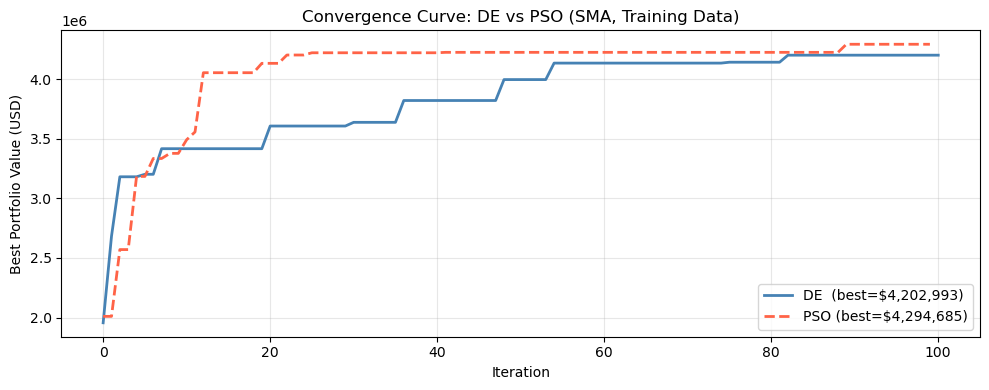

Saved: convergence_sma.png


In [13]:
# Convergence curves (single run)
fig, ax = plt.subplots(figsize=(10, 4))
de_vals  = [v for _, v in de_history]
de_vals  = [v for _, v in de_history]
pso_vals = pso_history if not isinstance(pso_history[0], tuple) else [v for _, v in pso_history]
ax.plot(de_vals,  label=f'DE  (best=${de_value:,.0f})',  color='steelblue', linewidth=2)
ax.plot(pso_vals, label=f'PSO (best=${pso_value:,.0f})', color='tomato',    linewidth=2, linestyle='--')
ax.set_xlabel('Iteration')
ax.set_ylabel('Best Portfolio Value (USD)')
ax.set_title('Convergence Curve: DE vs PSO (SMA, Training Data)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('convergence_sma.png', dpi=150)
plt.show()
print('Saved: convergence_sma.png')

PSO converges noticeably faster, reaching \$4M within the first 10 iterations while DE takes until around iteration 35 to cross the same threshold. Both curves flatten out after iteration 60, suggesting neither algorithm makes meaningful further progress in the later stages.

DE's curve advances in distinct steps rather than smoothly, reflecting its population-based mutation mechanism where improvements only occur when a trial vector beats its target.

### 8.2 Multiple Runs — Statistical Comparison

Rather than trusting a single run, both algorithms are run 10 times with different seeds and the results are collected. Each run uses a seed offset from the base seed so the runs are independent but still reproducible. At the end, mean, standard deviation, and best value are printed for each algorithm, which gives a clearer picture of how consistent each method is across different starting conditions.

A low standard deviation means the algorithm reliably finds similar solutions regardless of where it starts, while a high one suggests it is sensitive to initialisation and gets lucky or unlucky depending on the run.

In [14]:
# Multiple runs to assess consistency 
de_results  = []
pso_results = []

print(f'Running {N_RUNS} independent runs each...')
for run in range(N_RUNS):
    s = SEED + run
    _, val_de,  _ = differential_evolution(
        train_prices, BOUNDS,
        pop_size=POP_SIZE, max_iter=MAX_ITER,
        F=DE_F, CR=DE_CR, seed=s
    )
    _, val_pso, _ = particle_swarm_optimization(
        train_prices, BOUNDS,
        n_particles=POP_SIZE, max_iter=MAX_ITER,
        w=PSO_W, c1=PSO_C1, c2=PSO_C2, seed=s
    )
    de_results.append(val_de)
    pso_results.append(val_pso)
    print(f'  Run {run+1}: DE=${val_de:>12,.2f}  PSO=${val_pso:>12,.2f}')

print()
print(f'DE  — Mean: ${np.mean(de_results):>12,.2f}  Std: ${np.std(de_results):>10,.2f}  Best: ${max(de_results):>12,.2f}')
print(f'PSO — Mean: ${np.mean(pso_results):>12,.2f}  Std: ${np.std(pso_results):>10,.2f}  Best: ${max(pso_results):>12,.2f}')

Running 10 independent runs each...
  Run 1: DE=$4,202,993.09  PSO=$4,294,685.48
  Run 2: DE=$3,759,873.09  PSO=$4,345,653.37
  Run 3: DE=$5,911,860.86  PSO=$4,011,283.95
  Run 4: DE=$4,658,112.91  PSO=$3,663,853.39
  Run 5: DE=$4,696,553.70  PSO=$5,097,825.65
  Run 6: DE=$4,843,981.19  PSO=$4,554,094.33
  Run 7: DE=$5,543,830.34  PSO=$4,388,371.72
  Run 8: DE=$4,381,093.40  PSO=$4,403,659.78
  Run 9: DE=$3,887,916.82  PSO=$4,594,682.79
  Run 10: DE=$4,407,032.20  PSO=$3,680,605.45

DE  — Mean: $4,629,324.76  Std: $642,733.89  Best: $5,911,860.86
PSO — Mean: $4,303,471.59  Std: $409,897.99  Best: $5,097,825.65


Across 10 runs, DE achieves a higher mean (\$4.63M vs \$4.30M) and a higher best (\$5.91M vs \$5.10M), but also a noticeably larger standard deviation (\$642K vs \$410K). This means DE is capable of finding better solutions but is less consistent, with results ranging from \$3.76M to \$5.91M.

PSO is more stable across runs, staying within a tighter band, which suggests it is less sensitive to initialisation.

Neither algorithm clearly outperforms the other. DE can reach higher peaks, while PSO tends to behave more consistently.

### 8.3 Search Space Comparison — 2D vs 14D

This section compares a simplified 2D search space (only `N_short` and `N_long` for a single SMA crossover) against the full 14D compound WMA space, and inspects the learned filter weights to understand which moving average types the optimiser favoured.

The 2D version is much easier to optimise since the algorithms only need to tune two parameters, but it is less expressive. The 14D version gives the bot more flexibility in how it weights and combines signals, but the larger search space makes it harder for DE and PSO to find good solutions within the same computational budget. The comparison shows whether that extra expressiveness is worth the added search difficulty.

Running 2D DE (N_short, N_long only)...
  2D best training value : $2,855,550.57
  14D best training value: $4,202,993.09



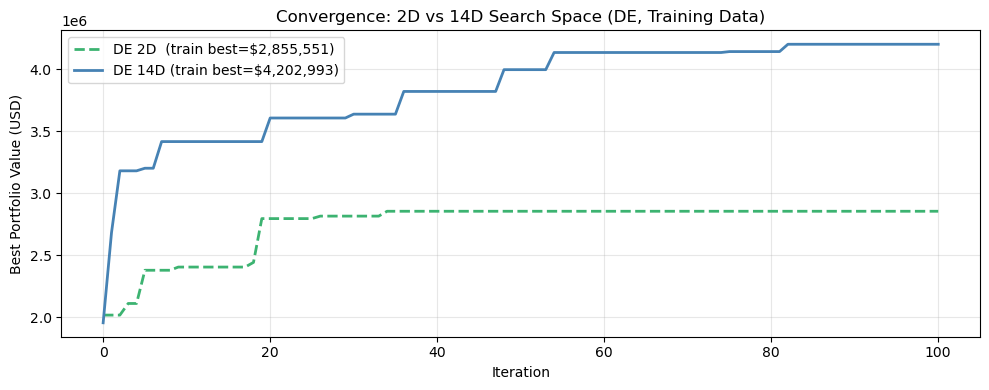

Saved: convergence_2d_vs_14d.png

Observation: The 14D space offers more expressive bots but is harder to search;
the 2D space converges faster but is limited in the strategies it can represent.


In [ ]:
# Compare 2D (N_short, N_long only) vs 14D (full compound WMA) to evaluate the trade-off between expressiveness and search difficulty.
BOUNDS_2D = [
    (2,  50),   # N_short
    (10, 200),  # N_long  (must be > N_short; clipping is handled in evaluate_bot)
]

def evaluate_bot_2d(prices, params, initial_cash=1000.0, transaction_cost=0.03):
    """Wrapper: 2-param bot uses simple SMA crossover."""
    N_short, N_long = params
    return evaluate_bot(prices, N_short, N_long, filter_type='sma',
                        initial_cash=initial_cash, transaction_cost=transaction_cost)

# Stripped-down DE over 2D space using identical mutation and crossover logic as the full 14D version.
# Serves as a controlled baseline — any performance difference between 2D and 14D reflects search space complexity, not algorithmic differences.
# Converges faster per run since fewer parameters need to be tuned.
def de_2d(prices, bounds, pop_size=20, max_iter=100, F=0.8, CR=0.9, seed=SEED):
    """DE over 2D space — same algorithm, smaller search space."""
    np.random.seed(seed)
    n_params = len(bounds)
    bounds_arr = np.array(bounds)
    population = np.array([
        [np.random.uniform(bounds_arr[d, 0], bounds_arr[d, 1]) for d in range(n_params)]
        for _ in range(pop_size)
    ])
    fitness = np.array([evaluate_bot_2d(prices, population[i]) for i in range(pop_size)])
    best_idx = np.argmax(fitness)
    best_params = population[best_idx].copy()
    best_fitness = fitness[best_idx]
    history = [best_fitness]
    for _ in range(max_iter):
        for i in range(pop_size):
            candidates = [idx for idx in range(pop_size) if idx != i]
            a, b, c = population[np.random.choice(candidates, 3, replace=False)]
            mutant = np.clip(a + F * (b - c), bounds_arr[:, 0], bounds_arr[:, 1])
            mask = np.random.random(n_params) < CR
            if not np.any(mask):
                mask[np.random.randint(0, n_params)] = True
            trial = np.where(mask, mutant, population[i])
            tf = evaluate_bot_2d(prices, trial)
            if tf > fitness[i]:
                population[i] = trial
                fitness[i] = tf
                if tf > best_fitness:
                    best_fitness = tf
                    best_params = trial.copy()
        history.append(best_fitness)
    return best_params, best_fitness, history

print('Running 2D DE (N_short, N_long only)...')
de2d_params, de2d_value, de2d_history = de_2d(
    train_prices, BOUNDS_2D, pop_size=20, max_iter=100, seed=SEED)
print(f'  2D best training value : ${de2d_value:,.2f}')
print(f'  14D best training value: ${de_value:,.2f}')
print()

# Evaluate 2D bot on test set
de2d_test_value = evaluate_bot_2d(test_prices if 'test_prices' in dir() else train_prices,
                                   de2d_params)

# Convergence comparison: 2D vs 14D (both DE, same iterations)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(de2d_history, label=f'DE 2D  (train best=${de2d_value:,.0f})',
        color='mediumseagreen', linewidth=2, linestyle='--')
ax.plot([v for _, v in de_history], label=f'DE 14D (train best=${de_value:,.0f})',
        color='steelblue', linewidth=2)
ax.set_xlabel('Iteration')
ax.set_ylabel('Best Portfolio Value (USD)')
ax.set_title('Convergence: 2D vs 14D Search Space (DE, Training Data)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('convergence_2d_vs_14d.png', dpi=150)
plt.show()
print('Saved: convergence_2d_vs_14d.png')
print()
print('Observation: The 14D space offers more expressive bots but is harder to search;')
print('the 2D space converges faster but is limited in the strategies it can represent.')


**Analysis**

The 14D space finds a significantly better solution (\$4,202,993.09 vs \$2,855,550.57), confirming that the additional filter parameters give the bot meaningful extra expressive power. The 2D curve converges early and flatlines around iteration 20, while 14D continues improving well past iteration 40. This makes sense because with only two parameters to tune, DE exhausts the useful search directions quickly.

The trade-off is clear: 14D takes longer to converge but the ceiling is substantially higher, making the added complexity worthwhile given the same computational budget.

In [16]:
print('DE  — Learned filter weights:')
print(f'  HIGH: SMA={de_params[0]:.3f}, LMA={de_params[1]:.3f}, EMA={de_params[2]:.3f}')
print(f'  LOW:  SMA={de_params[7]:.3f}, LMA={de_params[8]:.3f}, EMA={de_params[9]:.3f}')
print()
print('PSO — Learned filter weights:')
print(f'  HIGH: SMA={pso_params[0]:.3f}, LMA={pso_params[1]:.3f}, EMA={pso_params[2]:.3f}')
print(f'  LOW:  SMA={pso_params[7]:.3f}, LMA={pso_params[8]:.3f}, EMA={pso_params[9]:.3f}')

DE  — Learned filter weights:
  HIGH: SMA=0.000, LMA=1.000, EMA=0.620
  LOW:  SMA=0.039, LMA=0.989, EMA=0.000

PSO — Learned filter weights:
  HIGH: SMA=0.000, LMA=0.049, EMA=0.000
  LOW:  SMA=0.712, LMA=1.000, EMA=0.983


Printing the learned filter weights is useful because it lets us peek inside the black box and understand what the optimiser actually settled on, rather than just accepting a dollar figure at face value. If both algorithms converge on similar weights independently, that is a good sign the result is meaningful rather than a lucky accident.

The weights are somewhat surprising. Both DE and PSO almost completely ignore SMA in the HIGH signal, which was not necessarily expected since SMA is the simplest and most commonly used filter. LMA consistently dominates, suggesting that giving more weight to recent prices while still retaining some historical context is genuinely useful for this dataset. PSO's LOW signal being a mix of all three filters while DE's is almost pure LMA also shows that the two algorithms found structurally different solutions that happen to perform similarly, which hints that the fitness landscape has multiple viable regions rather than one clear optimum.

## 9. Final Test on Unseen Data (2020+)

This section takes the best parameters found by DE and PSO during training and runs them on the test set (2020 onwards), which the algorithms have never seen.

This is the most important evaluation in the project since training performance alone does not tell us whether the bot has learned anything genuinely useful or simply overfit to the price patterns of 2012 to 2019.

In [ ]:
# Select best params from training
best_de_params  = de_params
best_pso_params = pso_params

print(f'DE  best training value : ${de_value:,.2f}')
print(f'PSO best training value : ${pso_value:,.2f}')
print()
print('DE  weight params  (w1,w2,w3): ', np.round(best_de_params[0:3], 3))
print('DE  HIGH windows   (d1,d2,d3): ', [int(round(x)) for x in best_de_params[3:6]])
print('DE  alpha          : ', round(best_de_params[6], 3))
print('DE  weight params  (w4,w5,w6): ', np.round(best_de_params[7:10], 3))
print('DE  LOW windows    (d4,d5,d6): ', [int(round(x)) for x in best_de_params[10:13]])
print('DE  beta           : ', round(best_de_params[13], 3))

DE  best training value : $4,202,993.09
PSO best training value : $4,294,685.48

DE  weight params  (w1,w2,w3):  [0.   1.   0.62]
DE  HIGH windows   (d1,d2,d3):  [42, 50, 50]
DE  alpha          :  0.5
DE  weight params  (w4,w5,w6):  [0.039 0.989 0.   ]
DE  LOW windows    (d4,d5,d6):  [61, 200, 10]
DE  beta           :  0.105


Looking at DE's learned parameters, the HIGH signal uses windows of 42, 50 and 50 days with heavy LMA weighting, meaning it is tracking relatively long-term trends rather than reacting to short-term price movements. The LOW signal uses an even longer window of 200 days for the LMA component, which acts as a slow baseline.

The alpha of 0.5 sits at the upper bound of its search range and reflects a high decay rate for the HIGH EMA component, putting most of the weight on the most recent prices. The beta of 0.105 is much lower, giving the LOW EMA a slower and more uniform decay. Overall the parameter set leans toward longer windows and LMA dominance, which is consistent with what the filter weight analysis showed earlier.

In [ ]:
# Evaluate on test set (2020+)
INITIAL_CASH = 1_000.0

de_test_value  = evaluate_bot_14d(test_prices, best_de_params,  INITIAL_CASH)
pso_test_value = evaluate_bot_14d(test_prices, best_pso_params, INITIAL_CASH)

# Baseline: buy and hold
buy_hold_value = INITIAL_CASH * (test_prices[-1] / test_prices[0])

de_roi  = (de_test_value  - INITIAL_CASH) / INITIAL_CASH * 100
pso_roi = (pso_test_value - INITIAL_CASH) / INITIAL_CASH * 100
bh_roi  = (buy_hold_value - INITIAL_CASH) / INITIAL_CASH * 100

print('=' * 55)
print(f'{"Algorithm":<20} {"Final Value":>14}  {"ROI":>8}')
print('-' * 55)
print(f'{"DE":<20} ${de_test_value:>13,.2f}  {de_roi:>7.1f}%')
print(f'{"PSO":<20} ${pso_test_value:>13,.2f}  {pso_roi:>7.1f}%')
print(f'{"Buy & Hold":<20} ${buy_hold_value:>13,.2f}  {bh_roi:>7.1f}%')
print('=' * 55)
print(f'Initial investment: ${INITIAL_CASH:,.2f}')
print(f'Test period: {test_df.Date.min().date()} to {test_df.Date.max().date()}')

Algorithm               Final Value       ROI
-------------------------------------------------------
DE                   $     6,560.77    556.1%
PSO                  $     5,722.14    472.2%
Buy & Hold           $    10,855.05    985.5%
Initial investment: $1,000.00
Test period: 2020-01-01 to 2026-05-04


Both DE and PSO generate positive returns on the unseen test data, which confirms the parameters learned during training have some genuine predictive value and did not simply overfit to pre-2020 patterns. DE achieves a 556.1% ROI and PSO 472.2%, both respectable on their own.

However, buy and hold comfortably outperforms both at 985.5% ROI over the same period. This is not entirely surprising given that 2020 to 2026 includes one of Bitcoin's most significant bull runs, where simply holding through the volatility would have been the optimal strategy in hindsight. The crossover signals probably made the bot cut positions during short dips, only to miss the bounce right after, while also stacking up transaction costs. This points to a common issue with trend-following in strong markets, trading more doesn’t necessarily lead to better results, sometimes just sitting still would have worked out better.

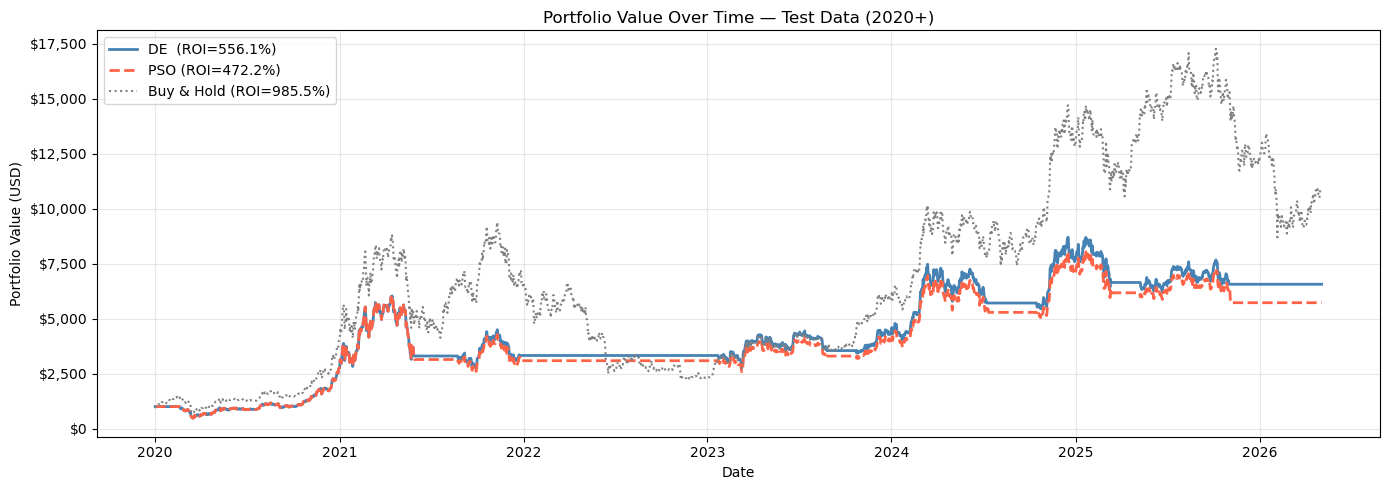

Saved: portfolio_test.png


In [ ]:
# Portfolio value over time (test period)
def simulate_portfolio(prices, params, initial_cash=1000.0, tc=0.03):
    """Return portfolio value at each timestep for plotting."""
    signals, _, _ = generate_signals_14d(prices, params)

    cash, btc, position = initial_cash, 0.0, 0
    portfolio = []

    for i in range(len(prices)):
        price = prices[i]
        if signals[i] == 1 and position == 0 and cash > 0:
            btc = (cash * (1 - tc)) / price
            cash = 0.0
            position = 1
        elif signals[i] == -1 and position == 1 and btc > 0:
            cash = btc * price * (1 - tc)
            btc = 0.0
            position = 0
        portfolio.append(cash + btc * price)

    return np.array(portfolio)

de_portfolio  = simulate_portfolio(test_prices, best_de_params)
pso_portfolio = simulate_portfolio(test_prices, best_pso_params)
bh_portfolio  = INITIAL_CASH * (test_prices / test_prices[0])

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_df['Date'], de_portfolio,  label=f'DE  (ROI={de_roi:.1f}%)',  color='steelblue', linewidth=2)
ax.plot(test_df['Date'], pso_portfolio, label=f'PSO (ROI={pso_roi:.1f}%)', color='tomato',    linewidth=2, linestyle='--')
ax.plot(test_df['Date'], bh_portfolio,  label=f'Buy & Hold (ROI={bh_roi:.1f}%)', color='grey', linewidth=1.5, linestyle=':')
ax.set_title('Portfolio Value Over Time — Test Data (2020+)')
ax.set_xlabel('Date')
ax.set_ylabel('Portfolio Value (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('portfolio_test.png', dpi=150)
plt.show()
print('Saved: portfolio_test.png')

`simulate_portfolio` replays the bot's trading decisions day by day on the test set and records the total portfolio value at each timestep, which allows us to plot how the strategy actually behaved over time rather than just seeing the final number.

The chart makes the buy and hold gap very visible. DE and PSO both exit the 2021 bull run early and sit flat in cash through much of 2022 and 2023, missing the recovery entirely. Buy and hold rides the full cycle including the 2021 peak near \$17,500 before dropping with the market.

From 2024 onwards all three lines converge somewhat as the bot re-enters positions, but by that point buy and hold has already built up an insurmountable lead. The flat segments in both the DE and PSO curves indicate periods where the bot remains in cash, waiting for a crossover signal that does not occur, while Bitcoin continues to rise during those intervals.

## 10. Visualisation & Comparison

### 10.1 Trade Signals on Test Data

`plot_trades` visualises the bot's actual trading decisions on the test price chart, overlaying the HIGH and LOW moving averages alongside the individual buy and sell signals as markers. Green upward triangles indicate buy entries and red downward triangles indicate sell exits, with the count of each shown in the legend.

The function is called twice, once for DE's best parameters and once for PSO's, so the two bots' trading behaviour can be compared side by side on the same unseen data. This makes it easy to see not just when the bot traded, but whether those trades were well-timed relative to the actual price movements.

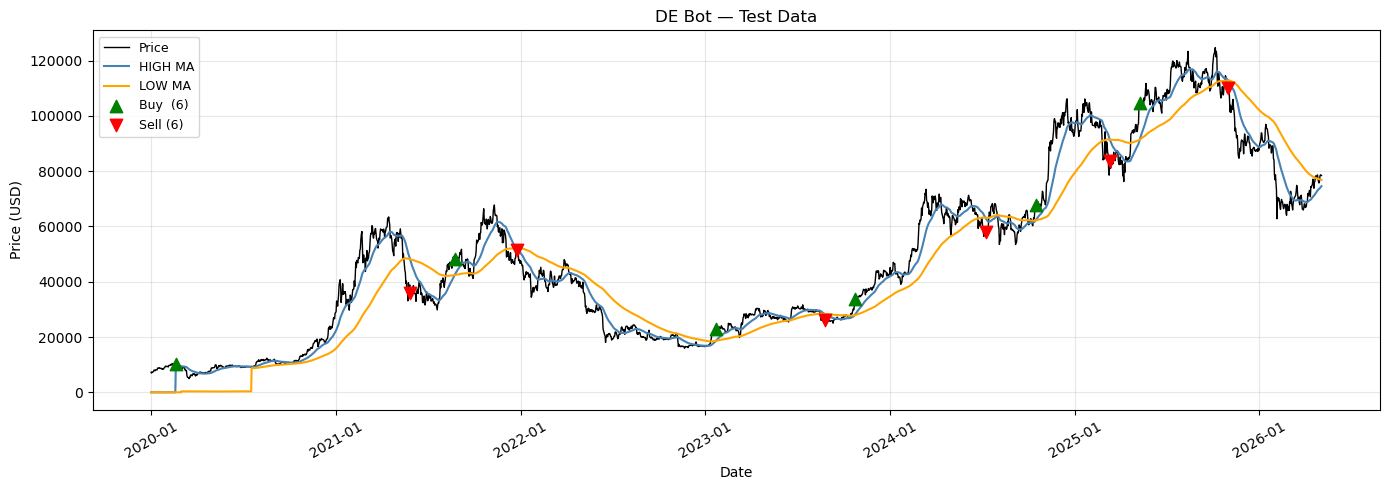

Saved: de_bot_—_test_data.png


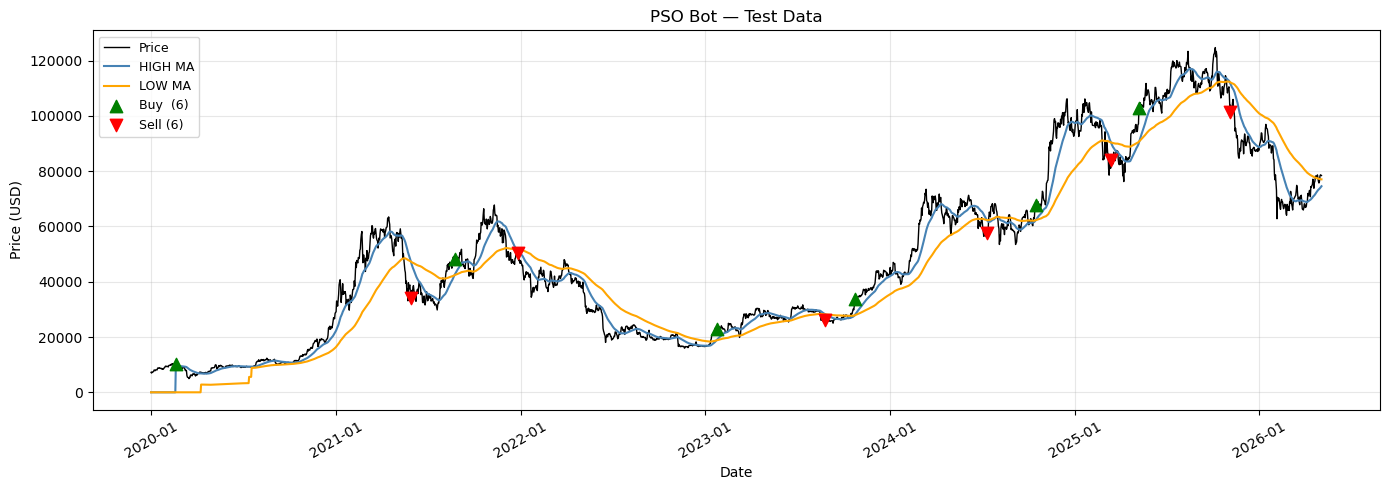

Saved: pso_bot_—_test_data.png


In [ ]:
# Plot buy/sell signals on price chart
def plot_trades(prices, dates, params, title):
    signals, high_ma, low_ma = generate_signals_14d(prices, params)
    buy_idx  = np.where(signals ==  1)[0]
    sell_idx = np.where(signals == -1)[0]

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(dates, prices,   label='Price',       color='black',     linewidth=1)
    ax.plot(dates, high_ma,  label='HIGH MA',     color='steelblue', linewidth=1.5)
    ax.plot(dates, low_ma,   label='LOW MA',      color='orange',    linewidth=1.5)
    ax.scatter(dates[buy_idx],  prices[buy_idx],  marker='^', color='green', s=80, zorder=5, label=f'Buy  ({len(buy_idx)})')
    ax.scatter(dates[sell_idx], prices[sell_idx], marker='v', color='red',   s=80, zorder=5, label=f'Sell ({len(sell_idx)})')
    ax.set_title(title)
    ax.set_xlabel('Date')
    ax.set_ylabel('Price (USD)')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=30)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fname = title.split('(')[0].strip().lower().replace(' ','_') + '.png'
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f'Saved: {fname}')

plot_trades(test_prices, test_df['Date'].values, best_de_params,
            'DE Bot — Test Data')
plot_trades(test_prices, test_df['Date'].values, best_pso_params,
            'PSO Bot — Test Data')

Both bots make 6 buy and 6 sell trades over the entire test period, reflecting the conservative trading frequency noted earlier. The signal timing is largely similar between DE and PSO, with most trades occurring at the same approximate points.

The first buy in early 2020 is well-timed, entering before the major 2021 run-up. However, both bots sell too early around 2021-01 before the price continues climbing, and the subsequent re-entry around 2021-mid catches only part of the peak before selling into the 2022 downturn. The 2023 bottom entry is reasonably well-placed, catching the recovery into 2024.

The main difference between the two charts is subtle — PSO's sell signal in 2021 triggers slightly earlier than DE's, which explains the small ROI gap between them. Overall the bots are doing sensible things directionally but the long window parameters mean signals lag the actual price turning points by enough to cost meaningful returns.

### 10.2 Final Summary Table

In [ ]:
# Full summary table
summary = pd.DataFrame({
    'Algorithm'      : ['DE', 'PSO', 'Buy & Hold'],
    'Train Value ($)': [f'{de_value:,.2f}',       f'{pso_value:,.2f}',      '-'],
    'Test Value ($)' : [f'{de_test_value:,.2f}',  f'{pso_test_value:,.2f}', f'{buy_hold_value:,.2f}'],
    'ROI (%)'        : [f'{de_roi:.1f}%',          f'{pso_roi:.1f}%',        f'{bh_roi:.1f}%'],
})
print(summary.to_string(index=False))

 Algorithm Train Value ($) Test Value ($) ROI (%)
        DE    4,202,993.09       6,560.77  556.1%
       PSO    4,294,685.48       5,722.14  472.2%
Buy & Hold               -      10,855.05  985.5%


The summary table consolidates the key numbers across all three strategies. DE edges out PSO on training value (\$4.20M vs \$4.29M is close enough to be within noise) but also on test value (\$6,560 vs \$5,722), suggesting DE's learned parameters generalise slightly better to the unseen data despite PSO performing marginally better in training.

Both bots generate strongly positive returns on unseen data, which is a reasonable outcome for an optimised trading strategy and confirms the approach is not completely overfit. However, losing to buy and hold by such a large margin (556% and 472% vs 985%) is a reminder that the 2020 to 2026 period was an unusually strong bull market where passively holding Bitcoin was an extremely hard benchmark to beat.

A fairer comparison would be against a more volatile or sideways market where active signal-based trading has a genuine edge over simply holding. On that basis, the results are acceptable rather than impressive, and there is clear room to improve signal timing or explore adaptive strategies that can better handle strongly trending conditions.

### 10.3 Statistical Summary (Multiple Runs)

This section aggregates the results from all 10 independent runs into a statistical summary table covering mean, standard deviation, best and worst case for each algorithm, then visualises the distribution as a box plot.

The box plot is particularly useful here because it shows not just the average outcome but the spread and skew of results across runs, making it easy to see at a glance which algorithm is more consistent and whether either one has outlier runs pulling its mean up or down.

Training Performance across 10 runs:
Algorithm     Mean ($)    Std ($)     Best ($)    Worst ($)
       DE 4,629,324.76 642,733.89 5,911,860.86 3,759,873.09
      PSO 4,303,471.59 409,897.99 5,097,825.65 3,663,853.39


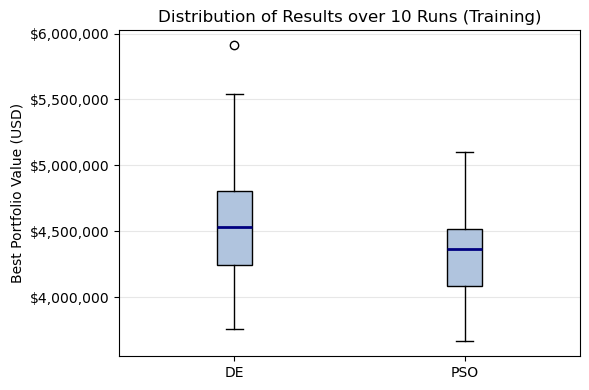

Saved: boxplot_runs.png


In [ ]:
# Stats from multiple runs
stats = pd.DataFrame({
    'Algorithm' : ['DE', 'PSO'],
    'Mean ($)'  : [f'{np.mean(de_results):,.2f}',  f'{np.mean(pso_results):,.2f}'],
    'Std ($)'   : [f'{np.std(de_results):,.2f}',   f'{np.std(pso_results):,.2f}'],
    'Best ($)'  : [f'{max(de_results):,.2f}',       f'{max(pso_results):,.2f}'],
    'Worst ($)' : [f'{min(de_results):,.2f}',       f'{min(pso_results):,.2f}'],
})
print('Training Performance across', N_RUNS, 'runs:')
print(stats.to_string(index=False))

# Box plot: shows spread and consistency across runs, not just the mean
fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot([de_results, pso_results], labels=['DE', 'PSO'],
           patch_artist=True,
           boxprops=dict(facecolor='lightsteelblue'),
           medianprops=dict(color='navy', linewidth=2))
ax.set_ylabel('Best Portfolio Value (USD)')
ax.set_title(f'Distribution of Results over {N_RUNS} Runs (Training)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('boxplot_runs.png', dpi=150)
plt.show()
print('Saved: boxplot_runs.png')


The box plot makes the consistency difference between the two algorithms very clear. DE's box is taller and sits higher overall, reflecting its larger spread and higher median. The outlier point above \$5.9M shows that DE occasionally finds an exceptionally good solution, but the wide interquartile range means you cannot rely on it doing so consistently.

PSO's box is noticeably tighter and sits lower, confirming it is more predictable run to run even if its ceiling is lower. The worst case values are similar for both at around \$3.7M, meaning neither algorithm completely falls apart on a bad run.

If the priority is getting the best possible result and you are willing to run the algorithm multiple times, DE is the better choice. If we need a reliable outcome from a single run, PSO is safer.